# Dependency Packages

In [ ]:
import mne
import numpy as np
from mne.channels import make_standard_montage
from mne.decoding import CSP
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold , train_test_split , GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
import os

# Parameter Setting

In [11]:
# GDF read dir path
gdf_dirPath = f'../../dataset/BCICIV_2a_gdf/'
# gdf_dirPath = f'../../dataset/BCICIV_2b_gdf/'

# EEG-MI 受試者
participants = []
participantsNum = 9
for i in range(1,participantsNum+1,1):
    participants = participants + [f'A0{i}T']  # bci4_2A
    # participants = participants + [f'B0{i}03T']  # bci4_2B

# Result store dir path
saveResultPath = './result_bci4_2a/'
# saveResultPath = './result_bci4_2b/'
try:
    os.mkdir(saveResultPath)
except:
    print("file exist")
    pass

# band pass filter
sfreq = 250
lowcut = 7
highcut = 30
filter_order = 4
filter_type = 'butter' # Butterworth
iir_params = dict(order=filter_order, ftype=filter_type)

# 769 左手, 770右手
target_keys = ['769', '770']  # bci4_2a and 2b

# 擷取實驗時間，0秒是cued開始
tmin = 0
tmax = 4

# CSP M值
M = 11

# BCI4 2A 資料集電擊轉換成標準10-20系統
channel_rename_map = {
    'EEG-Fz' : 'Fz'  ,
    'EEG-0'  : 'FC3' ,
    'EEG-1'  : 'FC1' ,
    'EEG-2'  : 'FCz' ,
    'EEG-3'  : 'FC2' ,
    'EEG-4'  : 'FC4' ,
    'EEG-5'  : 'C5'  ,
    'EEG-C3' : 'C3'  ,
    'EEG-6'  : 'C1'  ,
    'EEG-Cz' : 'Cz'  ,
    'EEG-7'  : 'C2'  ,
    'EEG-C4' : 'C4'  ,
    'EEG-8'  : 'C6'  ,
    'EEG-9'  : 'CP3' ,
    'EEG-10' : 'CP1' ,
    'EEG-11' : 'CPz' ,
    'EEG-12' : 'CP2' ,
    'EEG-13' : 'CP4' ,
    'EEG-14' : 'P1'  ,
    'EEG-Pz' : 'Pz'  ,
    'EEG-15' : 'P2'  ,
    'EEG-16' : 'POz' ,
    'EOG-left'   : 'EOG-left',
    'EOG-central': 'EOG-central',
    'EOG-right'  : 'EOG-right'
}
channel_types = {
    'EEG-Fz' : 'eeg',
    'EEG-0'  : 'eeg',
    'EEG-1'  : 'eeg',
    'EEG-2'  : 'eeg',
    'EEG-3'  : 'eeg',
    'EEG-4'  : 'eeg',
    'EEG-5'  : 'eeg',
    'EEG-C3' : 'eeg',
    'EEG-6'  : 'eeg',
    'EEG-Cz' : 'eeg',
    'EEG-7'  : 'eeg',
    'EEG-C4' : 'eeg',
    'EEG-8'  : 'eeg',
    'EEG-9'  : 'eeg',
    'EEG-10' : 'eeg',
    'EEG-11' : 'eeg',
    'EEG-12' : 'eeg',
    'EEG-13' : 'eeg',
    'EEG-14' : 'eeg',
    'EEG-Pz' : 'eeg',
    'EEG-15' : 'eeg',
    'EEG-16' : 'eeg',
    'EOG-left'   : 'eog',
    'EOG-central': 'eog',
    'EOG-right'  : 'eog'
}

# BCI4 2B 資料集電擊轉換成標準10-20系統
# channel_rename_map = {
#     'EEG:C3' : 'C3'  ,
#     'EEG:Cz' : 'Cz'  ,
#     'EEG:C4' : 'C4'  ,
#     'EOG:ch01':'EOG:ch01',
#     'EOG:ch02':'EOG:ch02',
#     'EOG:ch03':'EOG:ch03'
# }
# channel_types = {
#     'EEG:C3'   : 'eeg',
#     'EEG:Cz'   : 'eeg',
#     'EEG:C4'   : 'eeg',
#     'EOG:ch01' : 'eog',
#     'EOG:ch02' : 'eog',
#     'EOG:ch03' : 'eog'
# }

# Filter

No data specified. Sanity checks related to the length of the signal relative to the filter order will be skipped.
Setting up band-pass filter from 7 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 7.00, 30.00 Hz: -6.02, -6.02 dB



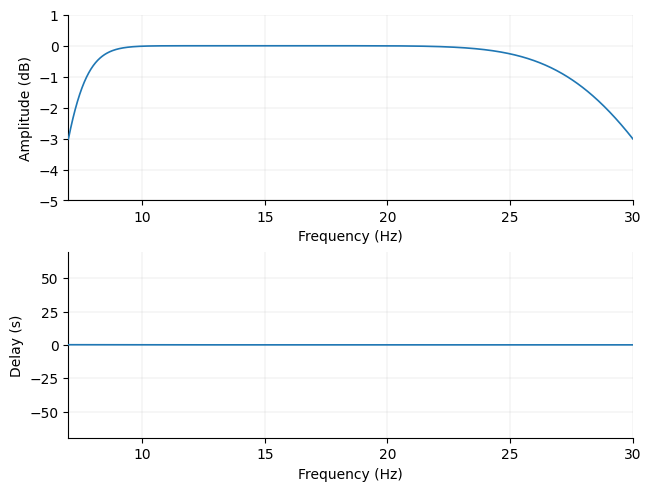

In [12]:
iir_coeffs = mne.filter.create_filter(
    data=None,           # data=None 時，僅計算係數
    sfreq=sfreq,
    l_freq=lowcut,
    h_freq=highcut,
    method='iir',
    iir_params=iir_params,
)

f = mne.viz.plot_filter(
    iir_coeffs,
    sfreq=sfreq,
    freq=[lowcut, highcut],
    fscale = "linear",
    alim = (-5,1),
    plot= ('magnitude', 'delay'),
    title=f'Butterworth Filter Frequency Response (Order={filter_order}, {lowcut}-{highcut} Hz)'
)
title=f'Butterworth Filter Frequency Response (Order={filter_order}, {lowcut}-{highcut} Hz)'
name = title.split(' ')
name = '_'.join(name) + ".png"
savePath = saveResultPath + f'./{name}'
f.savefig(savePath)

print()

# Data Segmentation and Splitting

In [13]:
montage = make_standard_montage('standard_1020')
eeg_only_channels = [
    name
    for name in channel_rename_map.values()
    if not name.startswith('EOG')
]

## Create Epoch training data and testing data
epochs_train = {}
epochs_test = {}
SEED = 42
for subject in participants:
    gdf_filepath = gdf_dirPath + f'./{subject}.gdf'
    try:
        raw = mne.io.read_raw_gdf(gdf_filepath, preload=True)
        print("GDF 檔案讀取成功。")
    except Exception as e:
        print(f"讀取 GDF 檔案時發生錯誤: {e}")
        raise
    ## Raw setting
    raw.set_channel_types(channel_types)
    raw.set_eeg_reference([])
    raw.rename_channels(channel_rename_map)
    raw.set_montage(montage, on_missing='ignore')

    ## Regression
    model = mne.preprocessing.EOGRegression(picks='eeg', picks_artifact='eog')
    model.fit(raw)
    raw = model.apply(raw)

    ## Remove EOG data in Epoch
    raw.pick_channels(eeg_only_channels)

    ## Filter
    raw.filter(
        l_freq=lowcut,
        h_freq=highcut,
        method='iir',       # 指定使用 IIR 濾波器
        iir_params=dict(order=filter_order, ftype='butter')
    )

    ## 選取事件做成epoch
    events, event_id = mne.events_from_annotations(raw)
    kept_event_ids = {
        key: value
        for key, value in event_id.items()
        if key in target_keys
    }
    events_of_interest = events[np.isin(events[:, 2], list(kept_event_ids.values()))]
    baseline = None
    epochs = mne.Epochs(
        raw,
        events_of_interest,
        event_id=kept_event_ids,
        tmin=tmin,
        tmax=tmax,
        baseline=baseline,
        preload=True,        # 將數據載入內存
        proj=False           # 暫時不應用投影
    )

    ## Data splitting
    y_all = epochs.events[:, 2]
    indices = np.arange(len(epochs))
    train_indices, test_indices, _, _ = train_test_split(
        indices, y_all,
        test_size=0.2,
        random_state=SEED,
        stratify=y_all # 確保標籤比例均衡
    )
    epochs_train[subject] = epochs[train_indices]
    epochs_test[subject] = epochs[test_indices]

Extracting EDF parameters from d:\User\Desktop\EEGsProgram\dataset\BCICIV_2a_gdf\A01T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


C:\Users\User\AppData\Local\Programs\Python\Python310\lib\contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


GDF 檔案讀取成功。
EEG channel type selected for re-referencing
EEG data marked as already having the desired reference.
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 7 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 7.00, 30.00 Hz: -6.02, -6.02 dB

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Not setting metadata
144 matching events found
No baseline correction applied
Using data from preloaded Raw for 144 events and 1001

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


GDF 檔案讀取成功。
EEG channel type selected for re-referencing
EEG data marked as already having the desired reference.
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 7 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 7.00, 30.00 Hz: -6.02, -6.02 dB

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Not setting metadata
144 matching events found
No baseline correction applied
Using data from preloaded Raw for 144 events and 1001

...

GDF 檔案讀取成功。
EEG channel type selected for re-referencing
EEG data marked as already having the desired reference.
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 7 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 7.00, 30.00 Hz: -6.02, -6.02 dB

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Not setting metadata
144 matching events found
No baseline correction applied
Using data from preloaded Raw for 144 events and 1001

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


GDF 檔案讀取成功。
EEG channel type selected for re-referencing
EEG data marked as already having the desired reference.
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 7 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 7.00, 30.00 Hz: -6.02, -6.02 dB

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Not setting metadata
144 matching events found
No baseline correction applied
Using data from preloaded Raw for 144 events and 1001

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


GDF 檔案讀取成功。
EEG channel type selected for re-referencing
EEG data marked as already having the desired reference.
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 7 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 7.00, 30.00 Hz: -6.02, -6.02 dB

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Not setting metadata
144 matching events found
No baseline correction applied
Using data from preloaded Raw for 144 events and 1001

# CSP

In [14]:
## CSP training
csp_train_results = {}
csp_test_results = {}
csp_list = {} # 儲存訓練好的csp
for subject in participants:
    n_components = 2*M
    csp = CSP(
        n_components=n_components,
        reg=None, # 正則化參數，通常保持 None
        log=True,
        transform_into='average_power' # 轉換成平均功率 (方差的對數)
    )
    X = epochs_train[subject].get_data()
    y = epochs_train[subject].events[:, 2]
    X_csp = csp.fit_transform(X, y)
    csp_list[subject] = csp
    csp_train_results[subject] = {
        'X_csp': X_csp,
        'y_csp': y,
    }

## CSP testing
for subject in participants:
    csp = csp_list[subject]
    X = epochs_test[subject].get_data()
    y = epochs_test[subject].events[:, 2]
    X_csp = csp.transform(X)
    csp_test_results[subject] = {
        'X_csp': X_csp,
        'y_csp': y,
    }

Computing rank from data with rank=None
    Using tolerance 3.3e-05 (2.2e-16 eps * 22 dim * 6.7e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.5e-05 (2.2e-16 eps * 22 dim * 7.3e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 4.3e-05 (2.2e-16 eps * 22 dim * 8.8e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMP

# Shape validation

In [15]:
print(f"subject: {subject}")
print(f"origin data shape: {epochs.get_data().shape}")
print(f"origin event shape: {epochs.events[:, 2].shape}")
print(f"training data shape: {epochs_train[subject].get_data().shape}")
print(f"training event shape: {epochs_train[subject].events[:,2].shape}")
print(f"testing data shape: {epochs_test[subject].get_data().shape}")
print(f"testing event shape: {epochs_test[subject].events[:,2].shape}")
print(f"csp training data shape: {csp_train_results[subject]['X_csp'].shape}")
print(f"csp testing data shape: {csp_test_results[subject]['X_csp'].shape}")

subject: A09T
origin data shape: (144, 22, 1001)
origin event shape: (144,)
training data shape: (115, 22, 1001)
training event shape: (115,)
testing data shape: (29, 22, 1001)
testing event shape: (29,)
csp training data shape: (115, 22)
csp testing data shape: (29, 22)


# Machine Learning

In [16]:
# ML
from sklearn.model_selection import StratifiedKFold
SEED = 42
svm = SVC(probability=True, random_state=SEED)
knn = KNeighborsClassifier()
lda = LinearDiscriminantAnalysis()

voting_clf = VotingClassifier(
        estimators=[("svm",svm),("knn",knn),('lda', lda)],
        voting='soft'
    )

# 創建管道
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', voting_clf)
])

# 參數網格
param_grid = {
    'classifier__svm__C': [0.1, 1, 10],
    'classifier__svm__kernel': ['rbf', 'linear'],
    'classifier__knn__n_neighbors': [5],
    'classifier__knn__weights': ['uniform', 'distance'],
    'classifier__lda__solver': ['svd', 'lsqr', 'eigen']
}

cv_fixed = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

classification_results = {}
best_models = {}
## ML training
for subject in participants:
    print(f"Subject {subject} Training Start.")
    # 獲取訓練數據
    X_train = csp_train_results[subject]['X_csp']
    y_train = csp_train_results[subject]['y_csp']
    # 網格搜索初始化
    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=cv_fixed,
        n_jobs=-1,
        verbose=1,
        scoring='accuracy',
        refit=True
    )
    grid_search.fit(X_train, y_train)
    best_models[subject] = grid_search

## ML testing
for subject in participants:
    print(f"Subject {subject} Testing Start.")
    best_subject_model = best_models[subject]
    X_test = csp_test_results[subject]['X_csp']
    y_test = csp_test_results[subject]['y_csp']
    y_pred = best_subject_model.predict(X_test)
    conf_matrix = confusion_matrix(csp_test_results[subject]['y_csp'], y_pred)
    classification_results[subject] = conf_matrix

Subject A01T Training Start.
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Subject A02T Training Start.
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Subject A03T Training Start.
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Subject A04T Training Start.
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Subject A05T Training Start.
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Subject A06T Training Start.
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Subject A07T Training Start.
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Subject A08T Training Start.
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Subject A09T Training Start.
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Subject A01T Testing Start.
Subject A02T Testing Start.
Subject A03T Testing Start.
Subject A04T Testing Start.
Subject A05T Testing Start.
Subject A06T Testing Start.
Subject A07T 

# Report Analysis

In [17]:
test_acc_all = {}
test_precision_all = {}
test_recall_all = {}
test_f1_all = {}
test_kappa_all = {}
for subject in participants:
    test_acc_all[subject] = []
    test_precision_all[subject] = []
    test_recall_all[subject] = []
    test_f1_all[subject] = []
    test_kappa_all[subject] = []

# 計算每個人的統計指標
for subject in participants:
    TP = classification_results[subject][0][0]
    TN = classification_results[subject][0][1]
    FN = classification_results[subject][1][0]
    FP = classification_results[subject][1][1]
    test_trials = classification_results[subject].sum()

    test_acc  = (TP+FP)/test_trials
    test_precision = TP/(TP+FN)
    test_recall = TP/(TP+TN)
    test_f1 = (2*test_precision*test_recall)/(test_precision+test_recall)
    test_pe = ((TP+FN)/test_trials)*((TP+TN)/test_trials)+((TN+FP)/test_trials)*((FN+FP)/test_trials)
    test_kappa = (test_acc-test_pe)/(1-test_pe)

    test_acc_all[subject]       = round(test_acc*100,1)
    test_precision_all[subject] = round(test_precision*100,1)
    test_recall_all[subject]    = round(test_recall*100,1)
    test_f1_all[subject]        = round(test_f1,2)
    test_kappa_all[subject]     = round(test_kappa,2)


test_acc_all['avg']         = round(np.mean(list(test_acc_all.values())), 1)
test_precision_all['avg']   = round(np.mean(list(test_precision_all.values())), 1)
test_recall_all['avg']      = round(np.mean(list(test_recall_all.values())), 1)
test_f1_all['avg']          = round(np.mean(list(test_f1_all.values())), 2)
test_kappa_all['avg']       = round(np.mean(list(test_kappa_all.values())), 2)

test_acc_all['std']         = round(np.std(list(test_acc_all.values())), 1)
test_precision_all['std']   = round(np.std(list(test_precision_all.values())), 1)
test_recall_all['std']      = round(np.std(list(test_recall_all.values())), 1)
test_f1_all['std']          = round(np.std(list(test_f1_all.values())), 2)
test_kappa_all['std']       = round(np.std(list(test_kappa_all.values())), 2)

# 創建表格
data = {
    'Subject'  : [subject for subject in participants] + ['Avg.'] + ['Std.'],
    'Accuracy' : [f"{test_acc_all[subject]:.1f}" for subject in participants] + [test_acc_all['avg']] + [test_acc_all['std']],
    'Precicion': [f"{test_precision_all[subject]:.1f}" for subject in participants] + [test_precision_all['avg']] + [test_precision_all['std']],
    'Recall'   : [f"{test_recall_all[subject]:.1f}" for subject in participants] + [test_recall_all['avg']] + [test_recall_all['std']],
    'F1-score' : [f"{test_f1_all[subject]:.2f}" for subject in participants] + [f"{test_f1_all['avg']:.2f}"] + [test_f1_all['std']],
    'Kappa'    : [f"{test_kappa_all[subject]:.2f}" for subject in participants] + [f"{test_kappa_all['avg']:.2f}"] + [test_kappa_all['std']]
}

df = pd.DataFrame(data)

print("--- 數據表格 ---")
print(df)

output_filename = saveResultPath + './stat_results.csv'
df.to_csv(
    output_filename,
    index=False        # 設置 index=False 來忽略 DataFrame 的索引列
)

print(f"\n數據已成功匯出到 '{output_filename}'，且不包含行索引。")

--- 數據表格 ---
   Subject Accuracy Precicion Recall F1-score Kappa
0     A01T     79.3      90.9   66.7     0.77  0.59
1     A02T     51.7      53.3   53.3     0.53  0.03
2     A03T     89.7      92.9   86.7     0.90  0.79
3     A04T     75.9      78.6   73.3     0.76  0.52
4     A05T     51.7      52.9   60.0     0.56  0.03
5     A06T     58.6      58.8   66.7     0.62  0.17
6     A07T     69.0      66.7   80.0     0.73  0.37
7     A08T    100.0     100.0  100.0     1.00  1.00
8     A09T     82.8      81.2   86.7     0.84  0.65
9     Avg.     73.2      75.0   74.8     0.75  0.46
10    Std.     15.1      15.9   13.3     0.14   0.3

數據已成功匯出到 './result_bci4_2a/./stat_results.csv'，且不包含行索引。


# Visualization

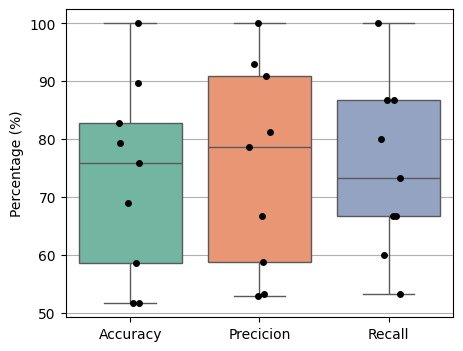

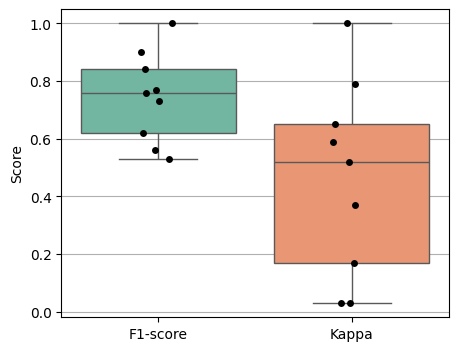

In [18]:
data1 = {
    'Accuracy' : [test_acc_all[subject] for subject in participants],
    'Precicion': [test_precision_all[subject] for subject in participants],
    'Recall'   : [test_recall_all[subject] for subject in participants]}
df1 = pd.DataFrame(data1)
fig = plt.figure(figsize=(5, 4))
sns.boxplot(data=df1, palette="Set2")
sns.stripplot(data=df1, color="black", size=5, jitter=True) # 疊加資料點
plt.ylabel(f'Percentage (%)')
plt.yticks(np.arange(50, 101, step=10))
plt.grid(axis='y')
plt.show()
title = 'acc_pre_rec.png'
name = title.split(' ')
name = '_'.join(name) + ".png"
name = saveResultPath + f'./{name}'
fig.savefig(name)

data2 = {
    'F1-score' : [test_f1_all[subject] for subject in participants],
    'Kappa'    : [test_kappa_all[subject] for subject in participants]}
df2 = pd.DataFrame(data2)
fig = plt.figure(figsize=(5, 4))
sns.boxplot(data=df2, palette="Set2")
sns.stripplot(data=df2, color="black", size=5, jitter=True) # 疊加資料點
plt.ylabel(f'Score')
plt.yticks(np.arange(0, 1.1, step=0.2))
plt.grid(axis='y')
plt.show()
title = 'f1_kappa.png'
name = title.split(' ')
name = '_'.join(name) + ".png"
name = saveResultPath + f'./{name}'
fig.savefig(name)


# Accuracy p-value Visualization

After vs Previous: t = 1.325, p-value = 0.2218
After vs Literal:  t = 3.240, p-value = 0.0119
Previous vs Literal:  t = 0.959, p-value = 0.3655


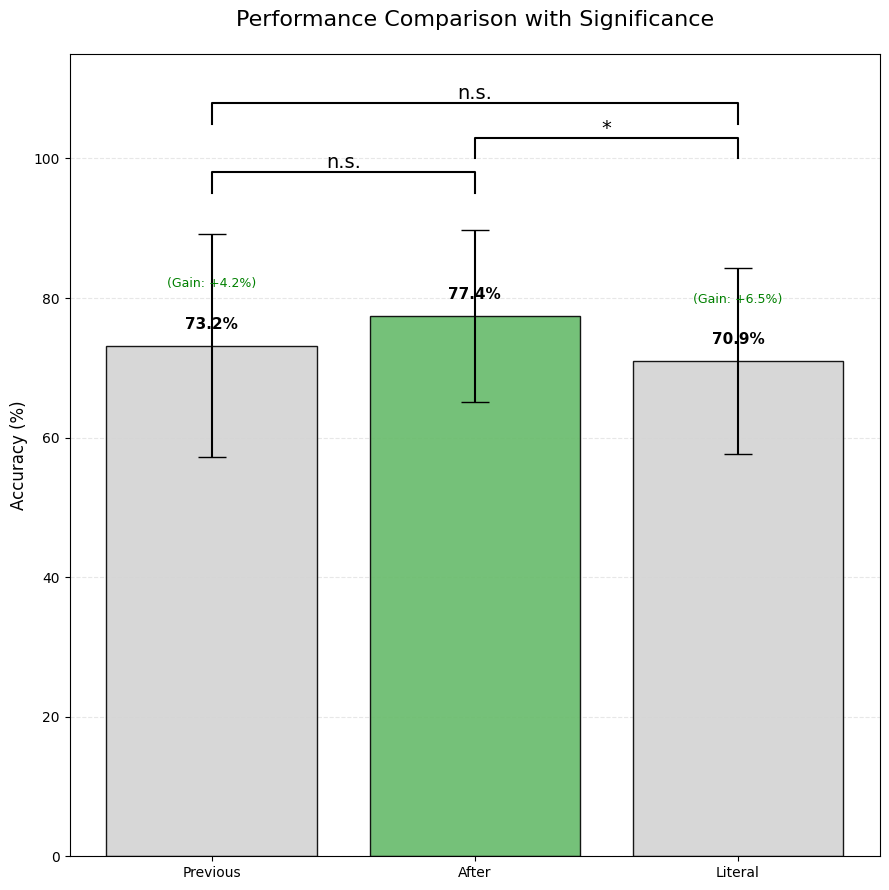

In [ ]:
# 您的原始數據
previous = np.array([79.3, 51.7, 89.7, 75.9, 51.7, 58.6, 69.0, 100.0, 82.8])
after    = np.array([79.3, 55.2, 96.6, 69.0, 72.4, 72.4, 79.3, 96.6, 75.9])
literal  = np.array([76.9, 57.1, 91.6, 65.5, 54.8, 58.3, 73.4, 92.8, 67.8])

def manual_paired_t_test(a, b):
    # 1. 計算差異值 (Differences)
    diff = a - b
    n = len(diff)

    # 2. 計算差異的平均值 (Mean of differences)
    d_mean = np.mean(diff)

    # 3. 計算差異的標準差 (Standard Deviation of differences)
    # ddof=1 使用樣本標準差
    d_std = np.std(diff, ddof=1)

    # 4. 計算 t 統計量: t = d_mean / (d_std / sqrt(n))
    t_stat = d_mean / (d_std / np.sqrt(n))

    # 5. 計算自由度與 p-value (雙尾檢定)
    df = n - 1
    p_val = stats.t.sf(np.abs(t_stat), df) * 2

    return t_stat, p_val

# 執行計算
t_prev_aft, p_prev_aft = manual_paired_t_test(after, previous)
t_aft_lit, p_aft_lit = manual_paired_t_test(after, literal)
t_pre_lit, p_pre_lit = manual_paired_t_test(previous, literal)

print(f"After vs Previous: t = {t_prev_aft:.3f}, p-value = {p_prev_aft:.4f}")
print(f"After vs Literal:  t = {t_aft_lit:.3f}, p-value = {p_aft_lit:.4f}")
print(f"Previous vs Literal:  t = {t_pre_lit:.3f}, p-value = {p_pre_lit:.4f}")

# 1. 數據定義
methods = ['Previous', 'After', 'Literal']
accuracy = [previous.mean(), after.mean(), literal.mean()]
std = [previous.std(), after.std(), literal.std()]
# 手算得到的 p-values (基於您提供的 9 位受試者數據)
# After vs Previous: 0.223
# After vs Literal: 0.046
p_vals = {('After', 'Previous'): p_prev_aft, ('After', 'Literal'): p_aft_lit, ('Previous', 'Literal'): p_pre_lit}

target_idx = 1
target_acc = accuracy[target_idx]

fig = plt.figure(figsize=(9, 9))

# 2. 繪圖設定
colors = ['#d3d3d3', '#66bb6a', '#d3d3d3']
bars = plt.bar(methods, accuracy, yerr=std, capsize=10,
               color=colors, edgecolor='black', alpha=0.9, zorder=2)

plt.title('Performance Comparison with Significance', fontsize=16, pad=20)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 115) # 提高上限以容納顯著性標籤
plt.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)

# 3. 標註顯著性連桿函式
def annotate_significance(idx1, idx2, p_val, y_base):
    x1, x2 = idx1, idx2
    y, h = y_base, 3
    # 畫連桿
    plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c='black')
    # 決定星號
    label = "*" if p_val < 0.05 else "n.s."
    plt.text((x1+x2)*.5, y+h, label, ha='center', va='bottom', color='black', fontsize=14)

# 執行標註
# After (index 1) vs Previous (index 0)
annotate_significance(0, 1, p_vals[('After', 'Previous')], 95)
# After (index 1) vs Literal (index 2)
annotate_significance(1, 2, p_vals[('After', 'Literal')], 100)
annotate_significance(0, 2, p_vals[('Previous', 'Literal')], 105)

# 4. 添加數值與 Gain 註解
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 2,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

    if i != target_idx:
        diff = target_acc - accuracy[i]
        plt.text(bar.get_x() + bar.get_width()/2, height + 8,
                 f'(Gain: +{diff:.1f}%)', ha='center', va='bottom', fontsize=9, color='green')

plt.tight_layout()
plt.show()
fig.savefig('comparison_chart.png')